In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
class Encoder(nn.Module):
    ''' This the encoder part of VAE

    '''
    def __init__(self, input_dim, hidden_dim, z_dim):
        '''
        Args:
            input_dim: A integer indicating the size of input (in case of MNIST 28 * 28).
            hidden_dim: A integer indicating the size of hidden dimension.
            z_dim: A integer indicating the latent dimension.
        '''
        super().__init__()

        self.linear = nn.Linear(input_dim, hidden_dim)
        self.mu = nn.Linear(hidden_dim, z_dim)
        self.var = nn.Linear(hidden_dim, z_dim)

    def forward(self, x):
        # x is of shape [batch_size, input_dim]

        hidden = F.relu(self.linear(x))
        # hidden is of shape [batch_size, hidden_dim]
        z_mu = self.mu(hidden)
        # z_mu is of shape [batch_size, latent_dim]
        z_var = self.var(hidden)
        # z_var is of shape [batch_size, latent_dim]

        return z_mu, z_var
class Decoder(nn.Module):
    ''' This the decoder part of VAE

    '''
    def __init__(self, z_dim, hidden_dim, output_dim):
        '''
        Args:
            z_dim: A integer indicating the latent size.
            hidden_dim: A integer indicating the size of hidden dimension.
            output_dim: A integer indicating the output dimension (in case of MNIST it is 28 * 28)
        '''
        super().__init__()

        self.linear = nn.Linear(z_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x is of shape [batch_size, latent_dim]

        hidden = F.relu(self.linear(x))
        # hidden is of shape [batch_size, hidden_dim]

        predicted = torch.sigmoid(self.out(hidden))
        # predicted is of shape [batch_size, output_dim]

        return predicted
class VAE(nn.Module):
    ''' This the VAE, which takes a encoder and decoder.

    '''
    def __init__(self, enc, dec):
        super().__init__()

        self.enc = enc
        self.dec = dec

    def forward(self, x):
        # encode
        z_mu, z_var = self.enc(x)

        # sample from the distribution having latent parameters z_mu, z_var
        # reparameterize
        std = torch.exp(z_var / 2)
        eps = torch.randn_like(std)
        x_sample = eps.mul(std).add_(z_mu)

        # decode
        predicted = self.dec(x_sample)
        return predicted, z_mu, z_var, x_sample

In [3]:
def sample_data(n_changepoints=4):
    trend = np.random.normal(0, 0.03, n_changepoints)
    intercept = np.random.normal(0, 5, n_changepoints)
    seasonal = np.random.normal(0, 2, 7)
    seasonal -= seasonal.mean()
    changepoints = np.cumsum(np.random.geometric(1/125, n_changepoints))
    data = []
    curr_section = 0
    for i in range(changepoints[:-1].sum()):
        if i >= changepoints[curr_section]:
            curr_section += 1
        if curr_section >= n_changepoints:
                curr_section = n_changepoints-1
        curr_seasonal = i%7
        data.append(trend[curr_section]*i + intercept[curr_section] + seasonal[curr_seasonal] + 
                    np.random.normal(0, 0.5))
    
    return np.array(data)

def vae_loss(x, xhat, z_mu, z_var):
    recon_loss = F.mse_loss(xhat, x)
    kl_loss = 0.5 * torch.sum(torch.exp(z_var) + z_mu**2 - 1.0 - z_var)
    
    loss = recon_loss + kl_loss
    
    return loss

def create_sliding_window(x, window_size=20):
    data_windowed = []
    for i in range(0, x.shape[0], window_size):
        curr = x[i:i+window_size]
        data_windowed.append(curr)
    return np.array(data_windowed[0:-1])

def sample_neighbors(x):
    indx_set = np.array([-1, 1])
    indexes = np.random.choice(indx_set, size=x.shape[0], replace=True)
    indexes[0] = 1
    indexes[-1] = -1
    neighbor_indexes = np.arange(x.shape[0]) + indexes
    return x[neighbor_indexes, :], neighbor_indexes

def add_trend(x, window=20):
    x_trend = torch.zeros(x.shape)
    for i in range(x.shape[0]):
        trend = np.random.normal(0.25, 0.25)
        addition = trend*np.arange(window)
        x_trend[i] = x[i] + addition
        
    return x_trend

In [4]:
data = sample_data()
data_windowed = np.lib.stride_tricks.sliding_window_view(data, 20)
data_windowed.shape

(398, 20)

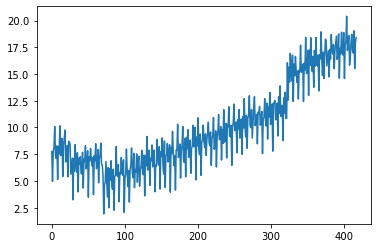

In [5]:
plt.plot(data)

In [6]:
x = torch.tensor(data_windowed).float()

In [7]:
encoder = Encoder(input_dim=20, hidden_dim=64, z_dim=2)
decoder = Decoder(z_dim=2, hidden_dim=64, output_dim=20)
vae = VAE(encoder, decoder)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3, betas=(0.9, 0.99))
tloss = nn.TripletMarginLoss(margin=1.0)
for epoch in range(800):
    optimizer.zero_grad()
    x_neighbors, neighbor_indexes = sample_neighbors(x) # sample positive examples
    x_trend = add_trend(x) # sample negative examples
    predicted, z_mu, z_var, z = vae(x)
    loss = vae_loss(x=x, xhat=predicted, z_mu=z_mu, z_var=z_var)
    _, _, _, z_pos = vae(x_neighbors)
    _, _, _, z_neg = vae(x_trend)
    triplet_loss = tloss(z, z_pos, z_neg)
    loss = loss + triplet_loss
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        print(loss.item())

5378.4990234375
124.60470581054688
113.3537368774414
106.35596466064453
102.35904693603516
100.44004821777344
99.32254028320312
98.36551666259766
97.77558898925781
97.21529388427734
96.79998779296875
96.38722229003906
96.11473083496094
95.77959442138672
95.5994644165039
95.41490173339844
